In [1]:
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_community.tools import DuckDuckGoSearchRun
from IPython.display import Image, display
import os
load_dotenv()

True

In [2]:
#Annotated

In [3]:
query = "Who won the Champions League final 2025?"

In [4]:
llm = ChatOpenAI(model=os.getenv("OPENAI_MODEL"), temperature=0)

In [5]:
llm.invoke(query)

AIMessage(content="I'm sorry, but I don't have information on the Champions League final for 2025.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 17, 'total_tokens': 35, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_2b9b3207a6', 'id': 'chatcmpl-D1YGDcJFZWL1mgIqqdADtaU3JOhYF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bf041-b518-77c0-95f3-f8eb6d3c2afa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 18, 'total_tokens': 35, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [6]:
duck_search = DuckDuckGoSearchRun()
duck_search.invoke(query)

"The 2025 UEFA Champions League final saw Paris Saint-Germain deliver one of the greatest final performances the competition has ever seen. With the win, PSG also completed only the 11th European treble of all time, as they added a UEFA Champions League title to their 2024-25 Ligue 1 and Coupe de France titles. PSG stormed past Inter Milan in the 2025 Champions League final . It won 5-0, by more goals than any Champions League finalist ever before. How did 2025 /26 Champions League qualifying work? Twenty-nine teams qualified directly for the league phase, with the final seven spots coming through qualifying, culminating in August's play-offs. PSG thoroughly dominated Inter 5-0 to win the Champions League Final on Saturday for the first time in club history."

In [7]:
class AgentState(TypedDict):
    #all the other messages extend/ inherit from the BaseMessage, so rather than using UNION, let's just use the BaseMessage
    messages:Annotated[Sequence[BaseMessage], add_messages] #add_messages = reducer

In [8]:
tools = [DuckDuckGoSearchRun()]

In [9]:
llm = ChatOpenAI(model=os.getenv("OPENAI_MODEL"), temperature=0).bind_tools(tools) #bind tools to our llm

In [10]:
def model_call(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content="You are my AI assistant, please answer my query to the best of your abilities")
    response = llm.invoke([system_prompt] + state["messages"])
    return {"messages":[response]}

In [11]:
def should_continue(state: AgentState)->str:
    state_messages = state["messages"] #copies the latest state into the "messages" variable
    last_message = state_messages[-1] #get only the last message
    
    #if the "latest" message doesnt have any required tool to call, let's just end it
    if(not last_message.tool_calls):
        print("end!")
        return "end" #end edge
    else:
        print("continuing!")
        return "continue" #continue edge

In [12]:
graph = StateGraph(AgentState)
graph.add_node("our_agent",model_call)

In [13]:
tool_node = ToolNode(tools=tools)

In [14]:
graph.add_node("tools",tool_node)

In [15]:
graph.add_edge(START,"our_agent")

In [16]:
graph.add_conditional_edges(
    "our_agent" #name of the origin node
    , should_continue #fork/ decision node
    ,{
        "continue":"tools"
        , "end":END
    }
    
)

graph.add_edge("tools","our_agent")

app = graph.compile()

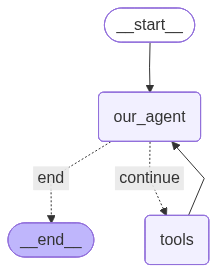

In [17]:
display(Image(app.get_graph().draw_mermaid_png()))

In [18]:
query = "Who won the Champions League final 2025?"

In [19]:
result = app.invoke({"messages":[HumanMessage(content=query)]})

continuing!
end!


In [24]:
for message in result["messages"]:
    print("*"*100)
    print(message)

****************************************************************************************************
content='Who won the Champions League final 2025?' additional_kwargs={} response_metadata={} id='d4928c49-0acf-4e9b-8f9f-0c4ce89f05b8'
****************************************************************************************************
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 100, 'total_tokens': 124, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_2b9b3207a6', 'id': 'chatcmpl-D1YGGC72q0ELkgWNABxGJdfkpfrqQ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019bf041-c223-7d91-a62f-cec6e975a32f-0' tool_calls=[{'name': 'd

In [25]:
result_stream = app.stream({"messages":[HumanMessage(content=query)]})

In [36]:
def print_stream(stream):
    for s in stream:
        print("*"*100)
        print(s)
        message = s[list(s.keys())[0]]["messages"][-1]
        if(isinstance(message,tuple)):
            print(message)
        else:
            message.pretty_print()

print_stream(app.stream({"messages":[HumanMessage(content=query)]}))

continuing!
****************************************************************************************************
{'our_agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 100, 'total_tokens': 124, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_2b9b3207a6', 'id': 'chatcmpl-D1YNwyNoh4kI1tUlDQ9mbAeLwUCim', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019bf049-0540-7ec3-86ac-a40da0af70c5-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Champions League final 2025 winner'}, 'id': 'call_blVyn83ScwGgzweeSJbrU4Is', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inpu